# Temperature Prediction

## Objective
Predict the **temperature** based on humidity data.


## Dataset Overview
The dataset contains hourly or daily readings of humidity and temperature.


## Workflow
1. Load the dataset  
2. Explore and clean the data  
3. Train a regression model  
4. Evaluate predictions


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
# Load the dataset
df = pd.read_csv("humidity.csv")
df.info()
df.head()


<class 'pandas.DataFrame'>
RangeIndex: 701548 entries, 0 to 701547
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   sensor_id    701548 non-null  int64  
 1   lat          701548 non-null  float64
 2   lon          701548 non-null  float64
 3   pressure     701548 non-null  float64
 4   temperature  701548 non-null  float64
 5   humidity     701548 non-null  float64
dtypes: float64(5), int64(1)
memory usage: 32.1 MB


,sensor_id,lat,lon,pressure,temperature,humidity
0,2266,42.738,23.272,95270.27,23.46,62.48
1,2292,42.663,23.273,94355.83,23.06,59.46
2,3096,42.700,23.360,95155.81,26.53,44.38
3,3428,42.624,23.406,94679.57,28.34,38.28
4,3472,42.669,23.318,94327.88,26.31,46.37


## Exploratory Data Analysis


In [3]:
# Check for missing values
print("-------missing values count in every column------\n")
print(df.isna().sum())

# Display summary statistics
print("----------------Summary statics-------------------\n")
df.describe()


-------missing values count in every column------

sensor_id      0
lat            0
lon            0
pressure       0
temperature    0
humidity       0
dtype: int64
----------------Summary statics-------------------



,sensor_id,lat,lon,pressure,temperature,humidity
count,701548.000000,701548.000000,701548.000000,701548.000000,701548.000000,701548.000000
mean,2835.419842,42.679722,23.333739,94965.292500,24.754990,48.348949
std,798.018890,0.025568,0.039365,2577.210945,14.013001,20.907247
min,1764.000000,42.622000,23.240000,0.000000,-145.120000,0.000000
25%,2224.000000,42.665000,23.310000,94528.017500,20.630000,34.140000
50%,2323.000000,42.685000,23.332000,95005.480000,24.780000,48.350000
75%,3474.000000,42.694000,23.360000,95405.132500,29.870000,62.940000
max,4661.000000,42.738000,23.419000,164926.750000,61.170000,100.000000


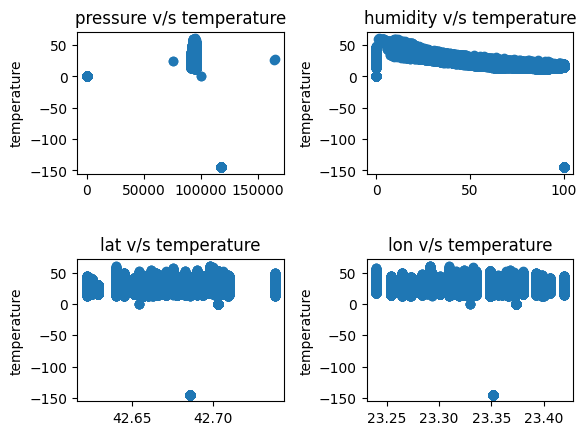

------------------------------------------------------------------------


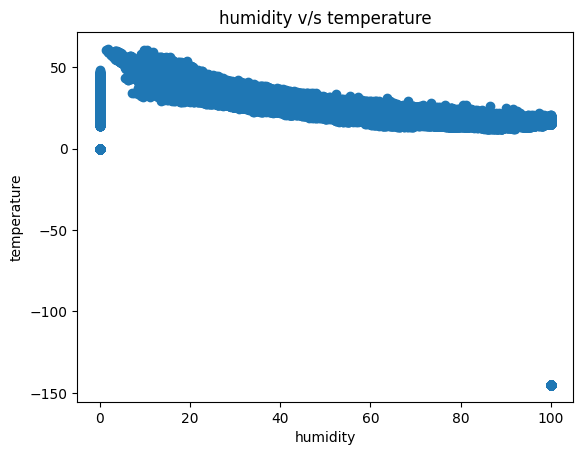


------------corelation-----------



,lat,lon,pressure,temperature,humidity
lat,1.000000,0.036192,0.168057,0.005760,0.060758
lon,0.036192,1.000000,0.112594,-0.017762,0.054816
pressure,0.168057,0.112594,1.000000,-0.547503,0.144252
temperature,0.005760,-0.017762,-0.547503,1.000000,-0.507828
humidity,0.060758,0.054816,0.144252,-0.507828,1.000000


In [4]:
# Scatter plot to observe relationship


print()
plt.subplot(2, 2, 1)
plt.scatter(df['pressure'], df['temperature'])
plt.title("pressure v/s temperature")
plt.ylabel('temperature')
plt.subplots_adjust(wspace=0.4, hspace=0.6)

plt.subplot(2, 2, 2)
plt.scatter(df['humidity'], df['temperature'])
plt.title("humidity v/s temperature")
plt.ylabel('temperature')

plt.subplot(2, 2, 3)
plt.scatter(df['lat'], df['temperature'])
plt.title("lat v/s temperature")
plt.ylabel('temperature')

plt.subplot(2, 2, 4)
plt.scatter(df['lon'], df['temperature'])
plt.title("lon v/s temperature")
plt.ylabel('temperature')
plt.show()

print("------------------------------------------------------------------------")
plt.scatter(df['humidity'], df['temperature'])
plt.title("humidity v/s temperature")
plt.ylabel('temperature')
plt.xlabel('humidity')
plt.show()



print("\n------------corelation-----------\n")
df1 = df[['lat','lon','pressure','temperature','humidity']]
df1.corr()

## Data Preprocessing

In [5]:
# Drop any rows with missing values
df_clean =  df.dropna()

# Define features and target
#        Target: 
#                temperature
#        features:
#                humidity
#                
#             
#                 

X = df_clean[['humidity']]
Y = df_clean[['temperature']]



# Train-test split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


## Model Training

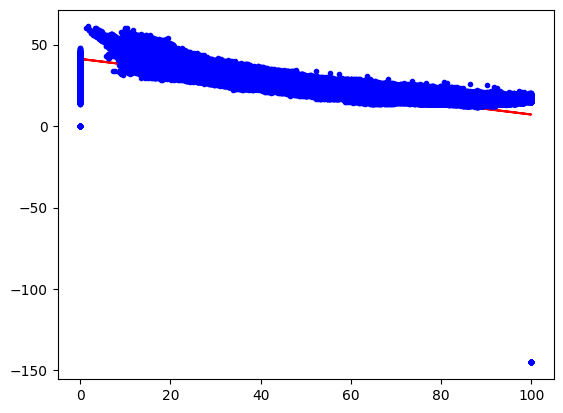

In [6]:
# Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

# Predict

y_pred = model.predict(X_test)

plt.plot(X_test,y_pred,color= 'r')
plt.plot(X,Y,"b.")
plt.show()

In [7]:
# Evaluate model performance
print("R² Score:", r2_score(y_test, y_pred))



R² Score: 0.25704416703650235


## Conclusion
- A simple linear regression model was used to predict temperature from humidity.  
- Consider using polynomial regression or time-series models for more complex patterns.


In [53]:
#applying Polynomial linear Regression
#degree 2
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=12)
x_train_trans = poly.fit_transform(X_train)
x_test_trans = poly.fit_transform(X_test)

In [54]:
lr = LinearRegression()
lr.fit(x_train_trans,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [55]:
y_predict = lr.predict(x_test_trans)


In [56]:
r2_score(y_test,y_predict)

0.8128508245947661